# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [16]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 2.

eps_r = 4.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=lc, lc=lc)


In [17]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [18]:
mesh.n_triangles

130

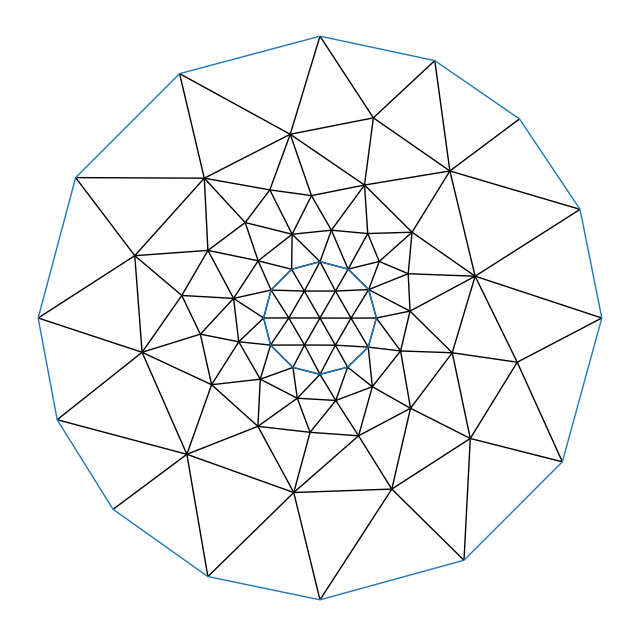

In [19]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

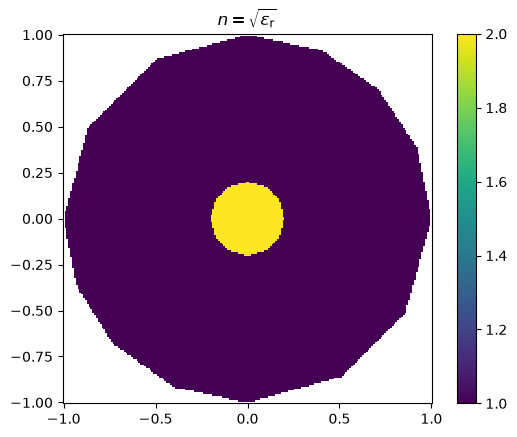

In [20]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [21]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [22]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)


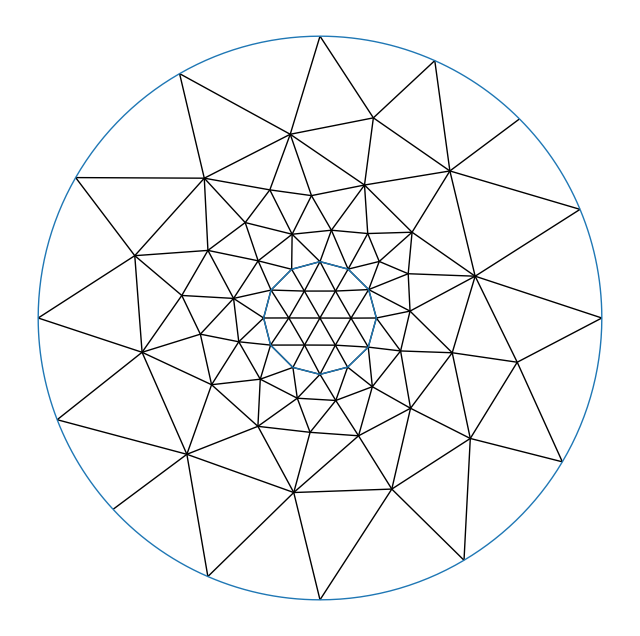

In [23]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [24]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [25]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [26]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [27]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [28]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [29]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 9
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [58]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 18
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [59]:
basis.N_DOF

2340

In [60]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [61]:
assembler._regions_RHS_term

[<Boundaries.D_OMEGA: 'd_Omega'>]

so we can set the problem:

In [62]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [ ]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 15.65edge/s]


region: d_Omega


Interior: 100%|██████████| 188/188 [00:00<00:00, 1100.28edge/s]


assembling non-local operators


NtD, Sigma:  57%|█████▋    | 8/14 [00:24<00:18,  3.03s/edge]

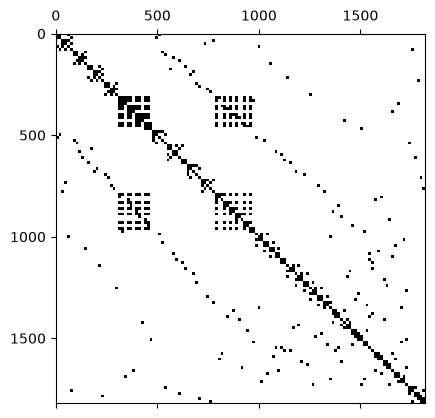

In [ ]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [ ]:
b = P.assemble_RHS()

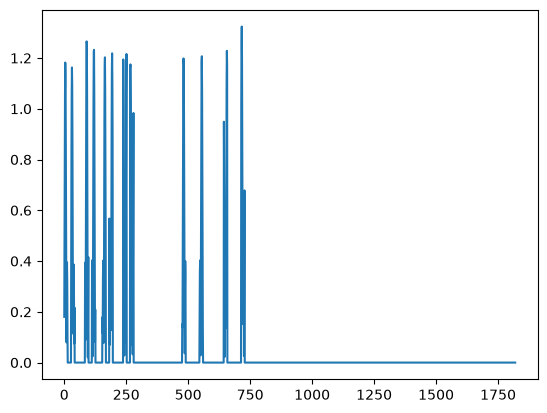

In [ ]:
import numpy as np 
plt.plot(np.abs(b))

In [ ]:
P.solve()

In [ ]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 1.11223589e+03-2.98697684e+03j, -2.73654908e+03+1.32791327e+03j,
         2.78340496e+03+4.39696395e+02j, ...,
         2.75394059e+03+6.80858012e+02j, -2.53200157e+03-1.68167080e+03j,
         1.21686022e+03+2.94374845e+03j],
       [-5.20893419e+01-1.11046438e+02j, -9.19160442e+01+9.03854744e+01j,
         1.30734119e+02+4.03352098e+01j, ...,
         5.70107065e+01-1.25523608e+02j, -8.58093031e+01+9.33913896e+01j,
         1.21314685e+02-1.10950663e+00j],
       [-4.10015116e+03-6.92408817e+03j, -1.40980850e+03+7.84181260e+03j,
         4.79369623e+03-6.13475106e+03j, ...,
         4.22349322e+03-6.39388132e+03j, -6.98132726e+03+3.64075565e+03j,
         7.78082820e+03+1.90805419e+03j],
       ...,
       [ 5.37429930e+00+2.96973005e+00j, -6.19839733e+00-1.94737157e-01j,
         6.41567777e+00-2.12171137e+00j, ...,
        -1.20411885e+00-9.20293647e+00j,  2.51139645e+00+7.53648729e+00j,
        -4.27456220e+00-5.38989879e+00j],
       [ 3.08729470e+01-1.85189301e+01j, -2.

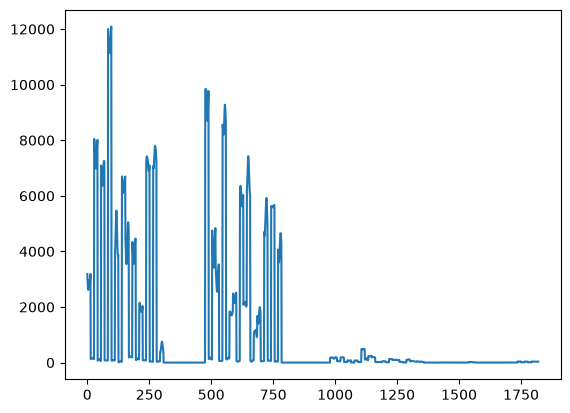

In [ ]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [ ]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [ ]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

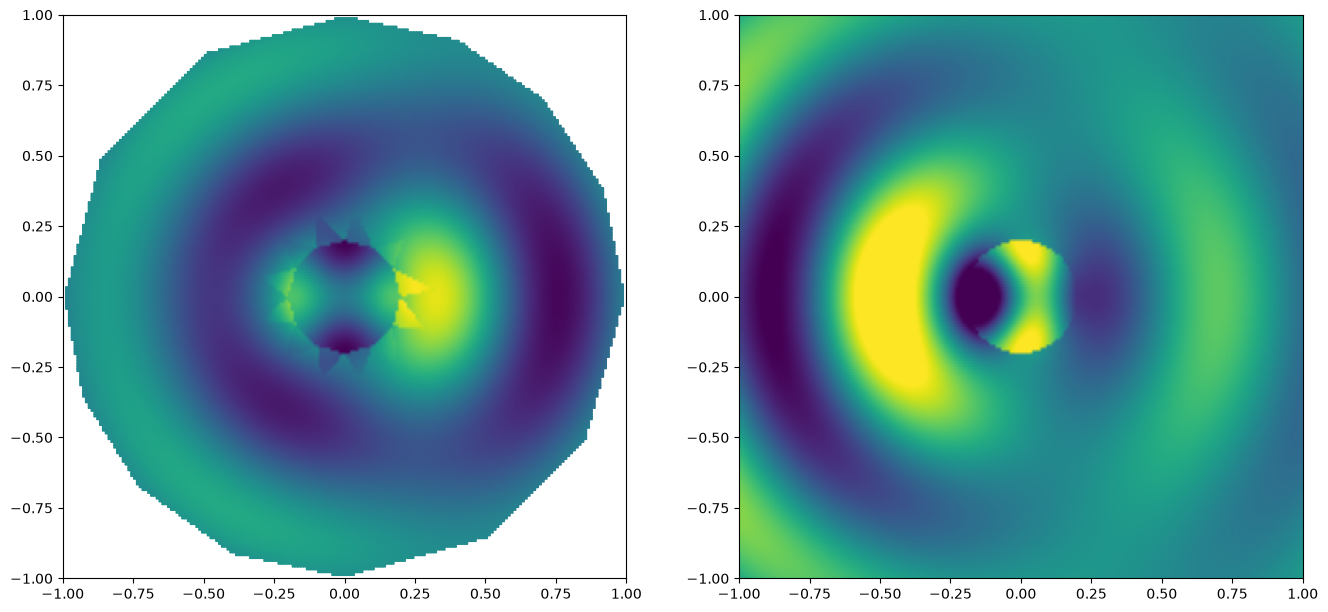

In [ ]:
import matplotlib.pyplot as plt
from cases.open_space.exact import nf_diel_cylinder_plane_wave
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

Z_exact = nf_diel_cylinder_plane_wave(X, Y, k, theta_inc=np.pi, eps_r=eps_r, c=np.array([0., 0.]), R=r)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')


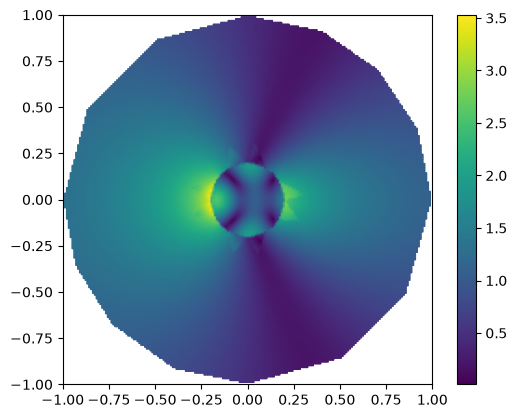

In [ ]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()